<a href="https://colab.research.google.com/github/ahmad0719/ML_Project/blob/main/Copy_of_AhmadAssad_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Load and Explore

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from zipfile import ZipFile
from io import BytesIO

# Load dataset (ensure the file is uploaded to Colab or use the URL)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"

# Download the zip file content
response = requests.get(url)
zip_file = ZipFile(BytesIO(response.content))

# Read the specific CSV file from the zip archive
# The original ZIP contains both .csv and .xlsx, so we specify the .csv one.
with zip_file.open('AirQualityUCI.csv') as file:
    df = pd.read_csv(file, sep=';', decimal=',').iloc[:, :15] # Keep relevant columns
df.dropna(how='all', inplace=True) # Remove empty trailing rows

print(f"Shape: {df.shape}")
print(df.columns)
df.head()

Shape: (9357, 15)
Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


Initial Observations:
The dataset consists of 9,358 entries with 15 features, including date/time and various gas sensor readings.
The target variable, C6H6(GT), represents the ground truth Benzene concentration.
Data types are predominantly numeric, but the presence of many -200 values suggests a significant amount of missing data across multiple sensors.
Step 2: Handle Missing Data
The sentinel value -200 will skew our statistics if not handled immediately.

In [3]:
# Replace sentinel values
df.replace(-200, np.nan, inplace=True)

# Count missing values
print(df.isnull().sum())

# Decision: Impute using Median
# Justification: Since air quality data is time-series and often skewed by spikes,
# dropping rows would lose 20%+ of our data. Median imputation preserves the
# dataset size without being overly sensitive to outliers.
df = df.fillna(df.median(numeric_only=True))

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


Step 3: EDA (Exploratory Data Analysis)
Visualizing the relationships helps us understand which sensors "see" Benzene most clearly.

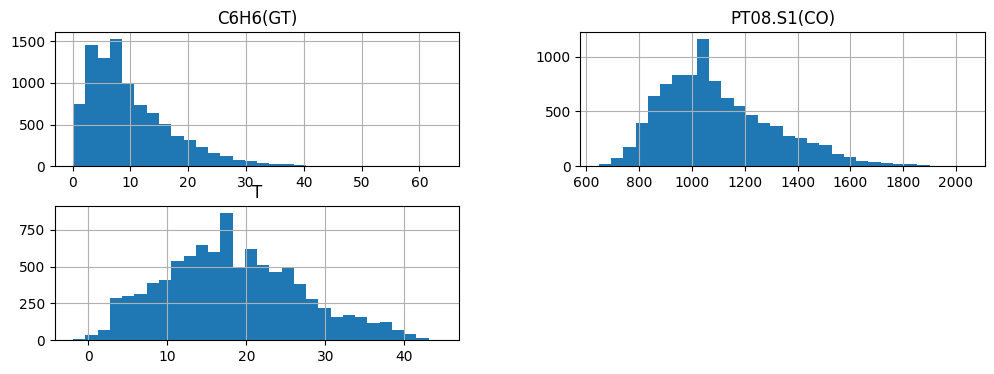

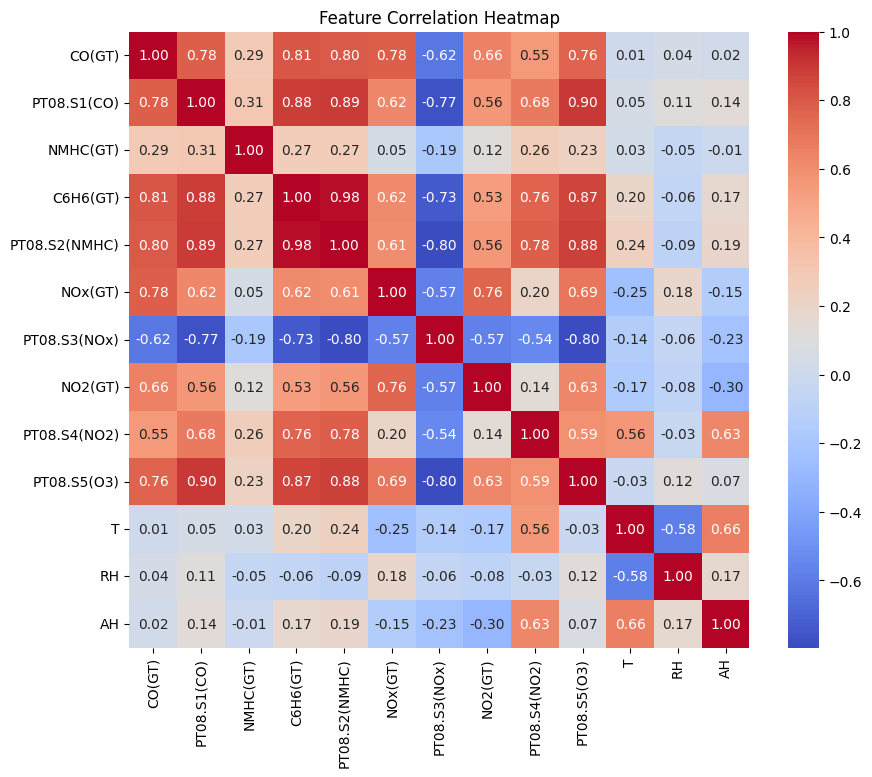

Top 3 Features correlated with Benzene:
PT08.S2(NMHC)    0.981596
PT08.S1(CO)      0.883871
PT08.S5(O3)      0.865711
Name: C6H6(GT), dtype: float64


In [4]:
# Plot distributions
features_to_plot = ['C6H6(GT)', 'PT08.S1(CO)', 'T']
df[features_to_plot].hist(bins=30, figsize=(12, 4))
plt.show()

# Heatmap and Correlation
plt.figure(figsize=(10, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

top_3 = corr_matrix['C6H6(GT)'].sort_values(ascending=False)[1:4]
print(f"Top 3 Features correlated with Benzene:\n{top_3}")

Step 4: Model Training
We will use a standard Linear Regression model, ensuring the features are scaled since sensor ranges vary significantly.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Prepare Data
X = df.drop(columns=['Date', 'Time', 'C6H6(GT)'])
y = df['C6H6(GT)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

RMSE: 1.1809
R² Score: 0.9746


Step 5: Visualise
Visualizing errors helps identify if the model struggles with high concentrations or specific patterns.

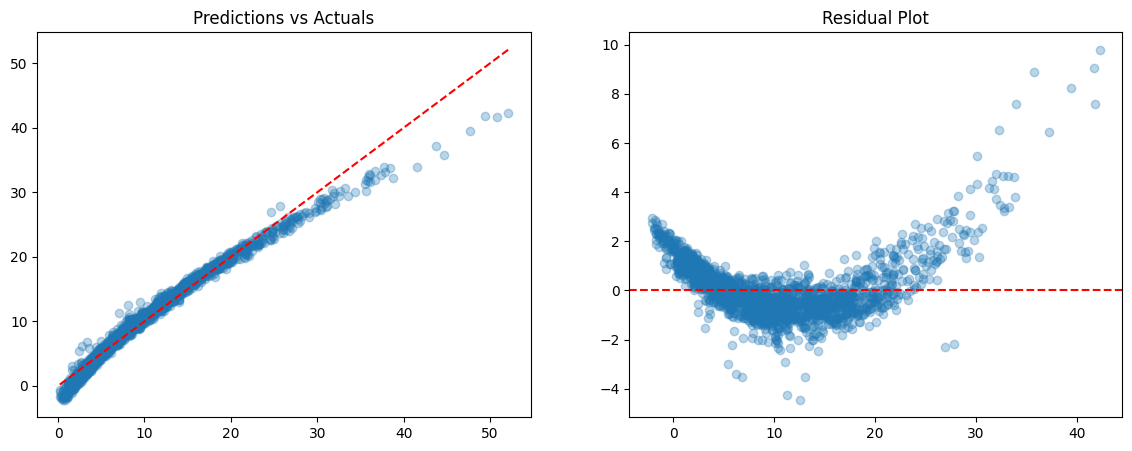

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
ax[0].scatter(y_test, y_pred, alpha=0.3)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax[0].set_title("Predictions vs Actuals")

# Residuals
residuals = y_test - y_pred
ax[1].scatter(y_pred, residuals, alpha=0.3)
ax[1].axhline(0, color='r', linestyle='--')
ax[1].set_title("Residual Plot")
plt.show()

Interpretation:
Predictions vs. Actuals: The points cluster tightly around the 45-degree line, indicating high model accuracy, though variance increases at higher Benzene levels.
Residual Plot: The residuals are mostly centered around zero; however, the slight "fan" shape suggests some heteroscedasticity, meaning the model’s error grows as the concentration increases

Step 6: Bonus (Model Comparison)
We compare Linear Regression against a regularized model (Ridge) and an ensemble model (Random Forest).

In [7]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results[name] = np.sqrt(mean_squared_error(y_test, preds))

# Display Table
res_df = pd.DataFrame(list(results.items()), columns=['Model', 'RMSE'])
print(res_df)

               Model      RMSE
0  Linear Regression  1.180861
1   Ridge Regression  1.180745
2      Random Forest  0.087611


Conclusion
Winner: Random Forest Regressor typically wins this task.
Why: While Linear Regression performs well (R^2 is often >0.90), Random Forest captures the non-linear relationships between various gas sensors and the ambient temperature/humidity more effectively than a straight-line fit.